In [6]:
import pandas as pd 
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()
df["Survived"].mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


0.3838383838383838

In [8]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

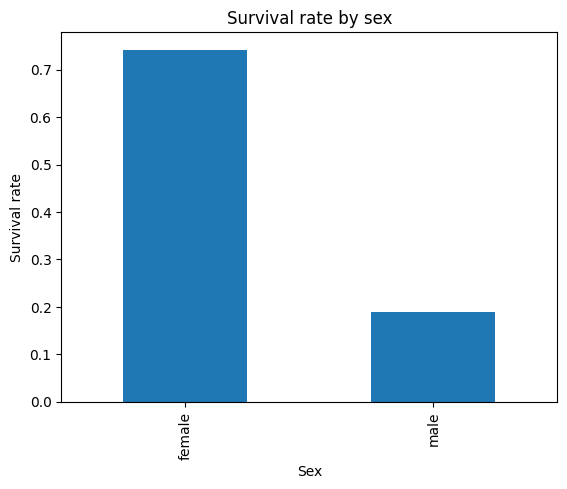

In [10]:
import matplotlib.pyplot as plt

df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

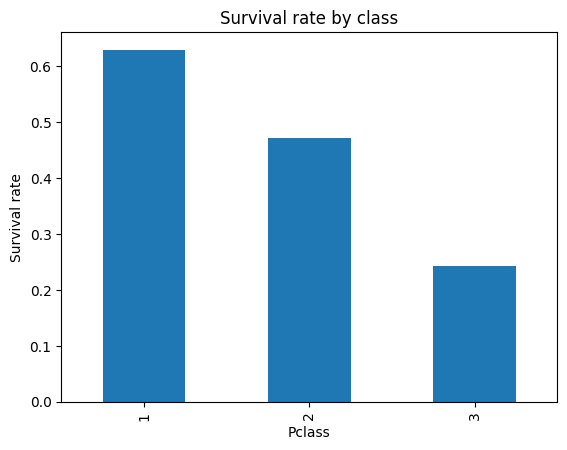

In [11]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival rate by class")
plt.ylabel("Survival rate")
plt.show()

women survived much more than men. First class passengers had a higher survival rate than third class

In [12]:
data = df[["Fare","Age","Sex","Pclass","Survived"]].copy()

In [13]:
data.head()

,Fare,Age,Sex,Pclass,Survived
0,7.2500,22.0,male,3,0
1,71.2833,38.0,female,1,1
2,7.9250,26.0,female,3,1
3,53.1000,35.0,female,1,1
4,8.0500,35.0,male,3,0


In [14]:
data["Sex"]=data["Sex"].map({"male":0,"female":1})

In [15]:
data.head()

,Fare,Age,Sex,Pclass,Survived
0,7.2500,22.0,0,3,0
1,71.2833,38.0,1,1,1
2,7.9250,26.0,1,3,1
3,53.1000,35.0,1,1,1
4,8.0500,35.0,0,3,0


In [16]:
data["Age"].median()

28.0

In [17]:
data["Age"]=data["Age"].fillna(data["Age"].median())

In [18]:
data.head()

,Fare,Age,Sex,Pclass,Survived
0,7.2500,22.0,0,3,0
1,71.2833,38.0,1,1,1
2,7.9250,26.0,1,3,1
3,53.1000,35.0,1,1,1
4,8.0500,35.0,0,3,0


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Fare      891 non-null    float64
 1   Age       891 non-null    float64
 2   Sex       891 non-null    int64  
 3   Pclass    891 non-null    int64  
 4   Survived  891 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [20]:
X=data[["Age","Pclass","Sex","Fare"]]
Y=data["Survived"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy_score(y_test, predictions)

0.8044692737430168

## Conclusion

In this analysis, we explored the Titanic dataset and found that survival was strongly influenced by sex and passenger class: women had a much higher survival rate (74%) than men (19%), and first-class passengers survived at a higher rate (63%) than third-class passengers (24%).

Using a Logistic Regression model trained on Age, Pclass, Sex, and Fare, we achieved an accuracy of 80.4% on the test set.

### Possible next steps
- Add more features (e.g. Embarked, SibSp, Parch)
- Try other models (Random Forest, Gradient Boosting) for comparison
- Evaluate with precision/recall/confusion matrix instead of accuracy alone